# LAB 1 — Predykcja szeregów czasowych: Aktywności słońca

Zadanie dotyczy doboru modelu SI dla cyklu słonecznego w kontekście liczby aktywności słońca

## 0. Importy i konfiguracja

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=9)

IMAGES_PATH = Path() / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## 1. Pobranie i wczytanie danych

In [2]:
# Pobranie miesięcznego datasetu (3310 próbek, 1749–2023)
sunspots_raw = sm.datasets.get_rdataset('sunspot.month', 'datasets').data
sunspots_raw.columns = ['YEAR', 'SUNACTIVITY']
sunspots_raw.to_csv('sunspot.csv', index=False)
print("Zapisano sunspot.csv")
print(sunspots_raw.head(10))
print(f"\nLiczba próbek: {len(sunspots_raw)}")
print(f"Zakres lat: {sunspots_raw['YEAR'].min():.2f} – {sunspots_raw['YEAR'].max():.2f}")

Zapisano sunspot.csv
          YEAR  SUNACTIVITY
0  1749.000000         96.7
1  1749.083333        104.3
2  1749.166667        116.7
3  1749.250000         92.8
4  1749.333333        141.7
5  1749.416667        139.2
6  1749.500000        158.0
7  1749.583333        110.5
8  1749.666667        126.5
9  1749.750000        125.8

Liczba próbek: 3310
Zakres lat: 1749.00 – 2024.75


## 2. Wizualizacja danych wejściowych

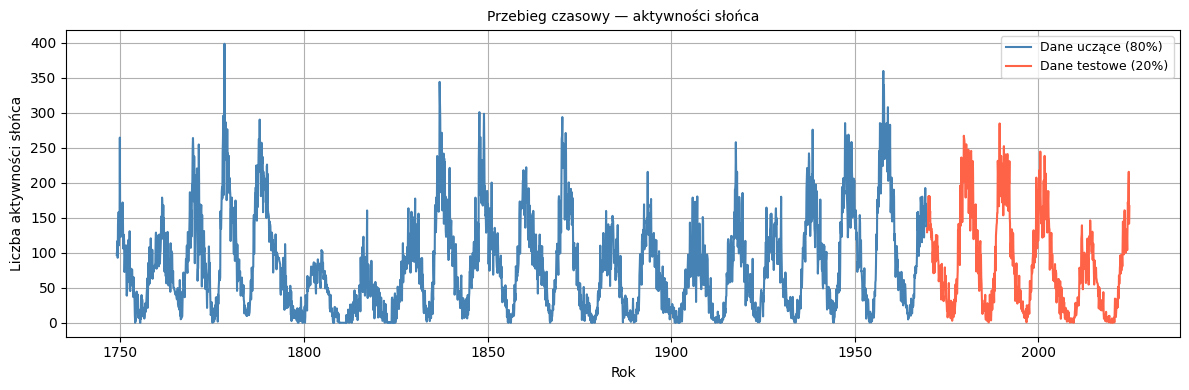

In [3]:
dane = pd.read_csv('sunspot.csv')
t = dane['YEAR'].values
y = dane['SUNACTIVITY'].values

# Podział 80/20
split = int(len(y) * 0.8)
t_train, t_test = t[:split], t[split:]
y_train, y_test = y[:split], y[split:]

plt.figure(figsize=(12, 4))
plt.plot(t_train, y_train, color='steelblue', label='Dane uczące (80%)')
plt.plot(t_test,  y_test,  color='tomato',    label='Dane testowe (20%)')
plt.xlabel('Rok')
plt.ylabel('Liczba aktywności słońca')
plt.title('Przebieg czasowy — aktywności słońca')
plt.legend()
plt.grid(True)
save_fig('01_dane_wejsciowe')
plt.show()

## 3. Model: Perceptron (dst)
Pojedynczy neuron z liniową funkcją aktywacji.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
from arch import arch_model

In [5]:
# Pomocnicza funkcja: tworzenie sekwencji AR
def create_sequences(data, look_back):
    X, Y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)

# Pomocnicza funkcja: metryki + testy reszt
def evaluate_model(y_true, y_pred, model_name):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    residuals = y_true - y_pred

    stat_sw, p_sw = stats.shapiro(residuals)
    stat_jb, p_jb = stats.jarque_bera(residuals)

    am = arch_model(residuals, vol='ARCH', p=1)
    res_arch = am.fit(disp='off')
    p_arch = res_arch.pvalues.get('alpha[1]', float('nan'))

    print(f"--- {model_name} ---")
    print(f"  R²={r2:.4f}  RMSE={rmse:.4f}")
    print(f"  Shapiro-Wilk  p={p_sw:.4f}  {'normalny' if p_sw>0.05 else 'NIEnormalny'}")
    print(f"  Jarque-Bera   p={p_jb:.4f}  {'normalny' if p_jb>0.05 else 'NIEnormalny'}")
    print(f"  ARCH test     p={p_arch:.4f} {'brak autokor.' if p_arch>0.05 else 'jest autokor.'}")
    return r2, rmse, residuals

C:\Users\Omen\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step
=== PERCEPTRON ===
--- Perceptron – uczące ---
  R²=0.8149  RMSE=29.3208
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0000 jest autokor.
--- Perceptron – testowe ---
  R²=0.8253  RMSE=28.9644
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0036 jest autokor.


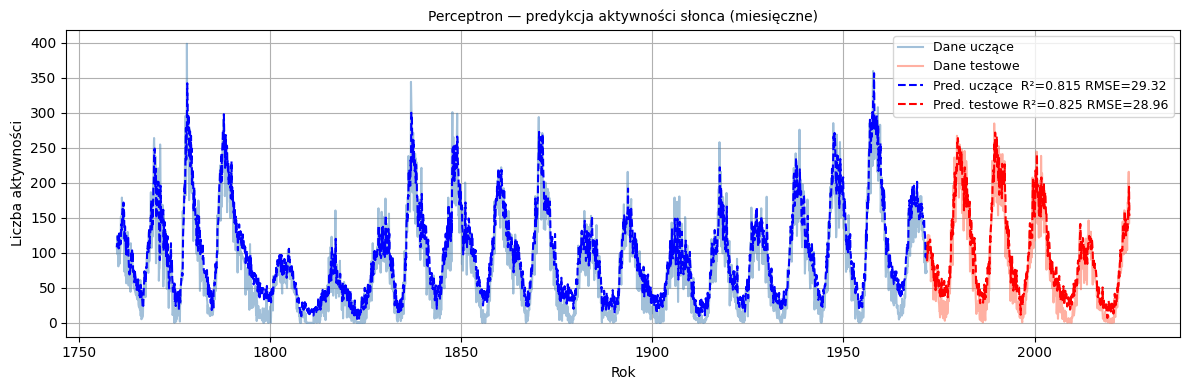

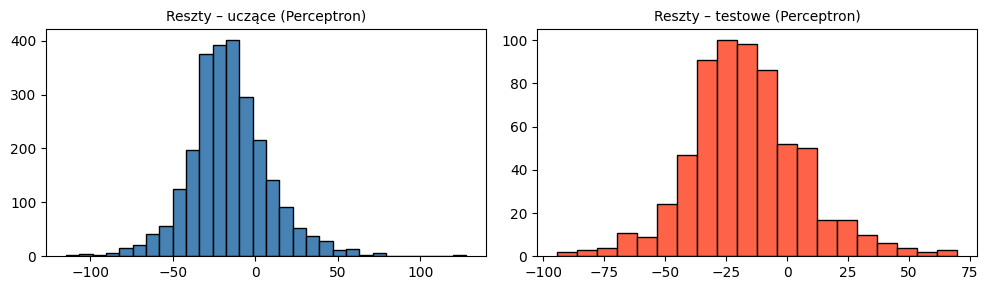

In [17]:
look_back = 132  # 11 lat * 12 miesięcy = 1 pełny cykl słoneczny

scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()

X_all, Y_all = create_sequences(y_scaled, look_back)
t_seq = t[look_back:]

split_seq = int(len(X_all) * 0.8)
X_tr, X_te = X_all[:split_seq], X_all[split_seq:]
Y_tr, Y_te = Y_all[:split_seq], Y_all[split_seq:]
t_tr_seq, t_te_seq = t_seq[:split_seq], t_seq[split_seq:]

# Perceptron
model_perc = Sequential([Dense(1, input_dim=look_back, activation='linear')])
model_perc.compile(optimizer=Adam(0.01), loss='mse')
model_perc.fit(X_tr, Y_tr, epochs=200, verbose=0)

y_pred_perc_tr = scaler.inverse_transform(model_perc.predict(X_tr)).flatten()
y_pred_perc_te = scaler.inverse_transform(model_perc.predict(X_te)).flatten()
y_tr_orig = scaler.inverse_transform(Y_tr.reshape(-1,1)).flatten()
y_te_orig = scaler.inverse_transform(Y_te.reshape(-1,1)).flatten()

print("=== PERCEPTRON ===")
r2_p_tr, rmse_p_tr, res_p_tr = evaluate_model(y_tr_orig, y_pred_perc_tr, 'Perceptron – uczące')
r2_p_te, rmse_p_te, res_p_te = evaluate_model(y_te_orig, y_pred_perc_te, 'Perceptron – testowe')

# Wykres
plt.figure(figsize=(12, 4))
plt.plot(t_tr_seq, y_tr_orig,      color='steelblue', alpha=0.5, label='Dane uczące')
plt.plot(t_te_seq, y_te_orig,      color='tomato',    alpha=0.5, label='Dane testowe')
plt.plot(t_tr_seq, y_pred_perc_tr, color='blue',      linestyle='--',
         label=f'Pred. uczące  R²={r2_p_tr:.3f} RMSE={rmse_p_tr:.2f}')
plt.plot(t_te_seq, y_pred_perc_te, color='red',       linestyle='--',
         label=f'Pred. testowe R²={r2_p_te:.3f} RMSE={rmse_p_te:.2f}')
plt.title('Perceptron — predykcja aktywności słonca (miesięczne)')
plt.xlabel('Rok'); plt.ylabel('Liczba aktywności'); plt.legend(); plt.grid(True)
save_fig('02_perceptron')
plt.show()

# Reszty
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(res_p_tr, bins=30, color='steelblue', edgecolor='k')
axes[0].set_title('Reszty – uczące (Perceptron)')
axes[1].hist(res_p_te, bins=20, color='tomato', edgecolor='k')
axes[1].set_title('Reszty – testowe (Perceptron)')
save_fig('02_perceptron_reszty')
plt.show()

## 4. Model: ARIMA (db)
Min. 3 różne zestawy hiperparametrów (P, D, Q).

--- ARIMA(2, 1, 2) – uczące ---
  R²=0.8581  RMSE=25.3999
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0000 jest autokor.
--- ARIMA(2, 1, 2) – testowe ---
  R²=0.8905  RMSE=22.7293
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0067 jest autokor.


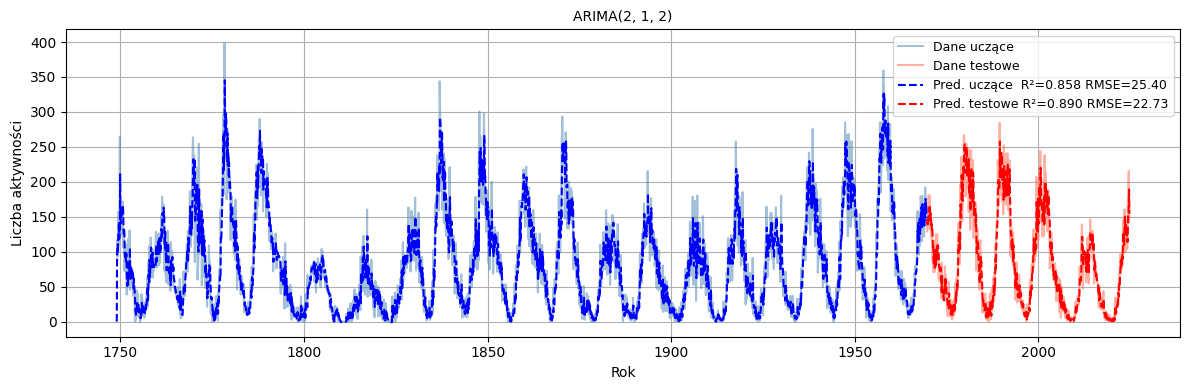

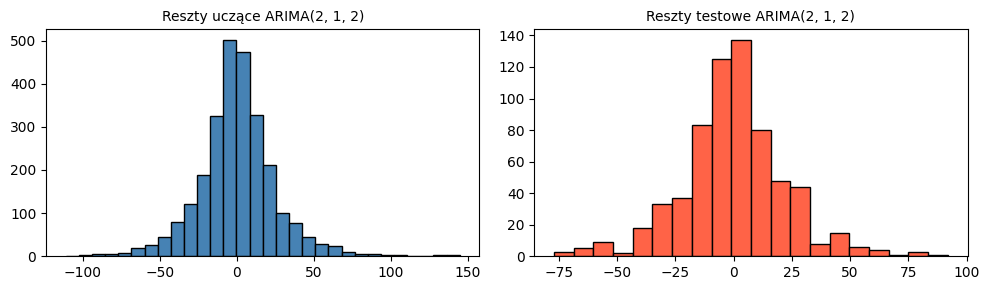

--- ARIMA(3, 1, 2) – uczące ---
  R²=0.8583  RMSE=25.3820
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0000 jest autokor.
--- ARIMA(3, 1, 2) – testowe ---
  R²=0.8893  RMSE=22.8460
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0048 jest autokor.


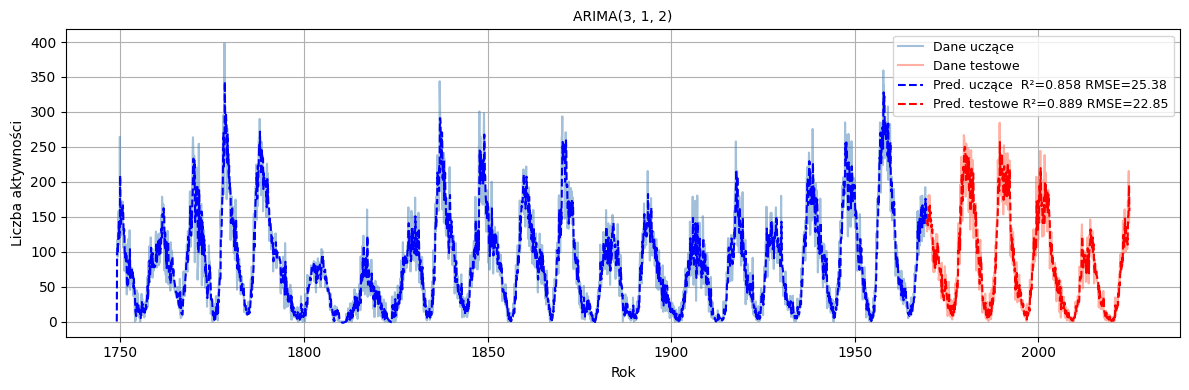

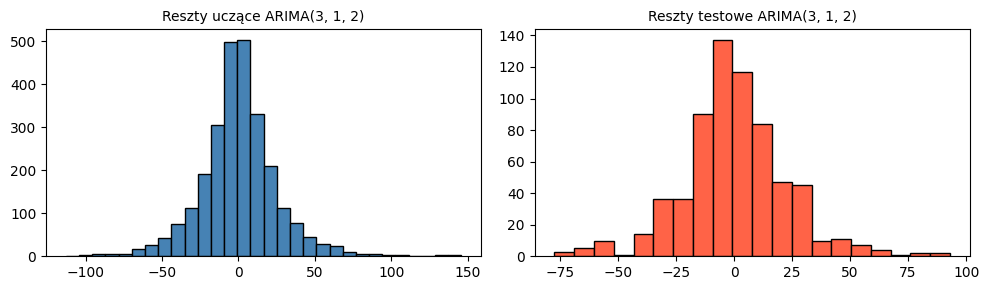

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_orders = [(2, 1, 2), (3, 1, 2), (5, 1, 1)]
arima_results = {}

for order in arima_orders:
    model = ARIMA(y_train, order=order)
    fitted = model.fit()

    pred_tr = fitted.fittedvalues

    # Rolling one-step-ahead forecast
    history = list(y_train)
    forecast_vals = []
    for i in range(len(y_test)):
        mod = ARIMA(history, order=order)
        mod_fit = mod.fit()
        yhat = mod_fit.forecast(steps=1)[0]
        forecast_vals.append(yhat)
        history.append(y_test[i])
    forecast = np.array(forecast_vals)

    r2_tr, rmse_tr, res_tr = evaluate_model(y_train, pred_tr,   f'ARIMA{order} – uczące')
    r2_te, rmse_te, res_te = evaluate_model(y_test,  forecast,  f'ARIMA{order} – testowe')
    arima_results[order] = dict(r2_tr=r2_tr, rmse_tr=rmse_tr,
                                r2_te=r2_te, rmse_te=rmse_te,
                                pred_tr=pred_tr, forecast=forecast,
                                res_tr=res_tr, res_te=res_te)

    plt.figure(figsize=(12, 4))
    plt.plot(t_train, y_train,   color='steelblue', alpha=0.5, label='Dane uczące')
    plt.plot(t_test,  y_test,    color='tomato',    alpha=0.5, label='Dane testowe')
    plt.plot(t_train, pred_tr,   color='blue', linestyle='--',
             label=f'Pred. uczące  R²={r2_tr:.3f} RMSE={rmse_tr:.2f}')
    plt.plot(t_test,  forecast,  color='red',  linestyle='--',
             label=f'Pred. testowe R²={r2_te:.3f} RMSE={rmse_te:.2f}')
    plt.title(f'ARIMA{order}')
    plt.xlabel('Rok'); plt.ylabel('Liczba aktywności'); plt.legend(); plt.grid(True)
    save_fig(f'03_arima_{order}')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(res_tr, bins=30, color='steelblue', edgecolor='k')
    axes[0].set_title(f'Reszty uczące ARIMA{order}')
    axes[1].hist(res_te, bins=20, color='tomato', edgecolor='k')
    axes[1].set_title(f'Reszty testowe ARIMA{order}')
    save_fig(f'03_arima_{order}_reszty')
    plt.show()

## 5. Model: NARNET (bdb)
Sieć neuronowa — min. 3 różne zestawy hiperparametrów.

C:\Users\Omen\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
=== NARNET h=10_lb=66m ===
--- NARNET h=10_lb=66m – uczące ---
  R²=0.8558  RMSE=25.7623
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0000 jest autokor.
--- NARNET h=10_lb=66m – testowe ---
  R²=0.8850  RMSE=23.2996
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0039 jest autokor.


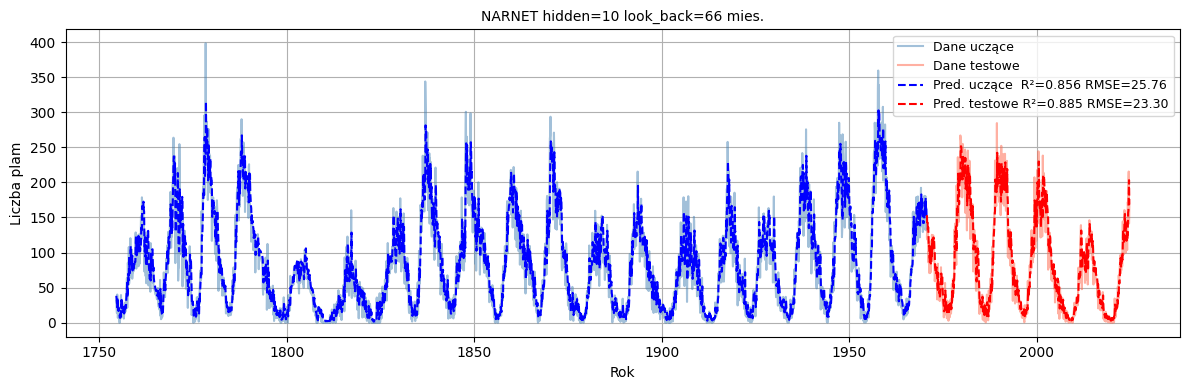

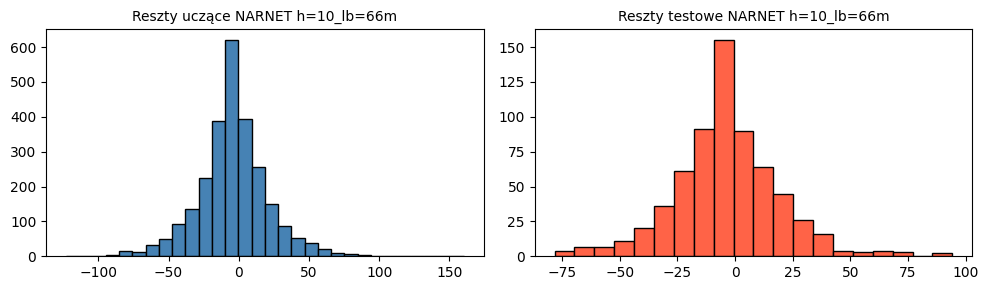

C:\Users\Omen\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
=== NARNET h=20_lb=132m ===
--- NARNET h=20_lb=132m – uczące ---
  R²=0.8715  RMSE=24.4311
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0000 jest autokor.
--- NARNET h=20_lb=132m – testowe ---
  R²=0.8956  RMSE=22.3925
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0058 jest autokor.


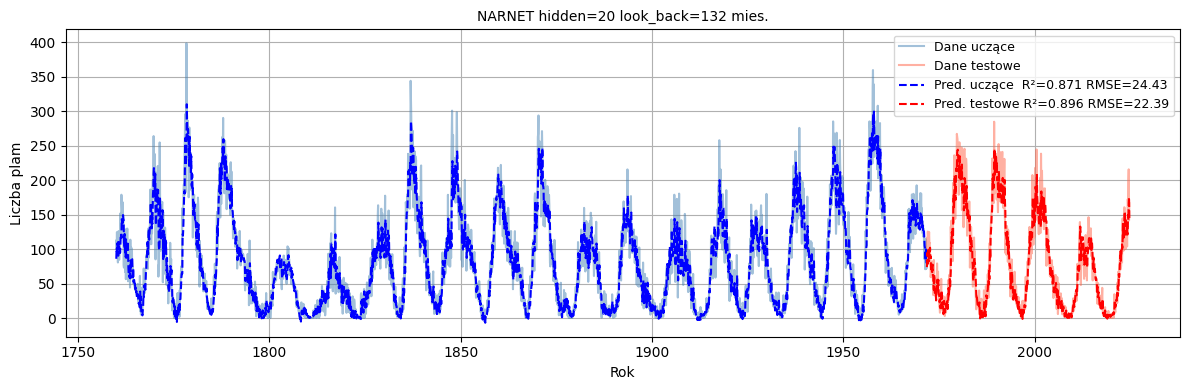

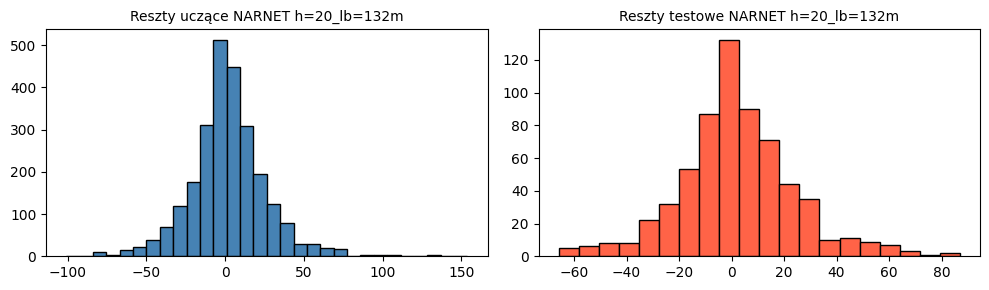

C:\Users\Omen\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== NARNET h=30_lb=198m ===
--- NARNET h=30_lb=198m – uczące ---
  R²=0.8722  RMSE=24.5277
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0000 jest autokor.
--- NARNET h=30_lb=198m – testowe ---
  R²=0.8947  RMSE=22.6873
  Shapiro-Wilk  p=0.0000  NIEnormalny
  Jarque-Bera   p=0.0000  NIEnormalny
  ARCH test     p=0.0028 jest autokor.


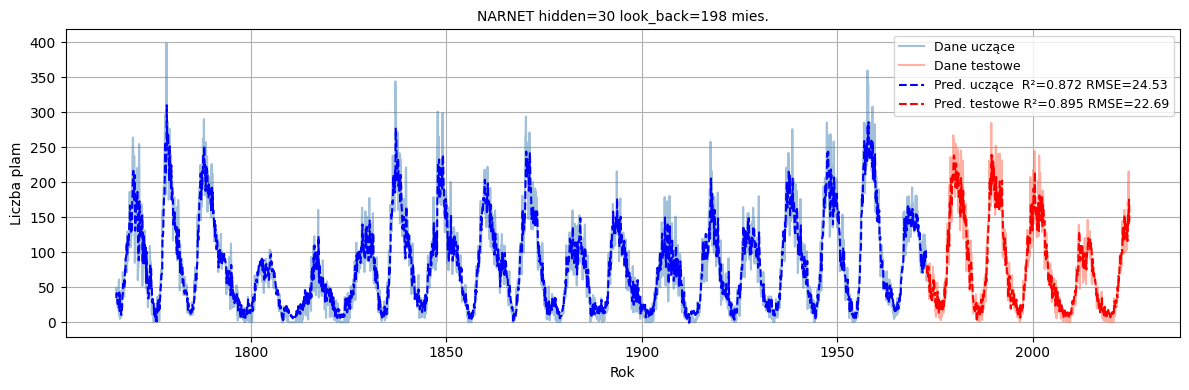

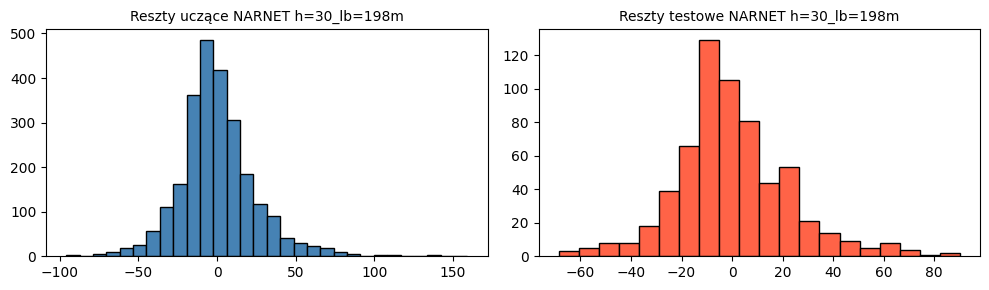

In [ ]:
from tensorflow.keras.layers import SimpleRNN

# (hidden_units, look_back) — look_back w miesiącach
narnet_params = [(10, 66), (20, 132), (30, 198)]  # 0.5, 1, 1.5 cyklu słonecznego
narnet_results = {}

for (hidden, lb) in narnet_params:
    scaler_n = MinMaxScaler()
    y_sc = scaler_n.fit_transform(y.reshape(-1, 1)).flatten()

    X_a, Y_a = create_sequences(y_sc, lb)
    sp = int(len(X_a) * 0.8)
    Xtr, Xte = X_a[:sp], X_a[sp:]
    Ytr, Yte = Y_a[:sp], Y_a[sp:]
    t_tr_n = t[lb:lb+sp]
    t_te_n = t[lb+sp:lb+len(X_a)]

    Xtr3 = Xtr.reshape(Xtr.shape[0], Xtr.shape[1], 1)
    Xte3 = Xte.reshape(Xte.shape[0], Xte.shape[1], 1)

    model_nar = Sequential([
        SimpleRNN(hidden, input_shape=(lb, 1)),
        Dense(1)
    ])
    model_nar.compile(optimizer='adam', loss='mse')
    model_nar.fit(Xtr3, Ytr, epochs=50, batch_size=32, verbose=0)

    yp_tr = scaler_n.inverse_transform(model_nar.predict(Xtr3)).flatten()
    yp_te = scaler_n.inverse_transform(model_nar.predict(Xte3)).flatten()
    yt_tr = scaler_n.inverse_transform(Ytr.reshape(-1,1)).flatten()
    yt_te = scaler_n.inverse_transform(Yte.reshape(-1,1)).flatten()

    label = f'h={hidden}_lb={lb}m'
    print(f"=== NARNET {label} ===")
    r2_tr, rmse_tr, res_tr = evaluate_model(yt_tr, yp_tr, f'NARNET {label} – uczące')
    r2_te, rmse_te, res_te = evaluate_model(yt_te, yp_te, f'NARNET {label} – testowe')
    narnet_results[label] = dict(r2_tr=r2_tr, rmse_tr=rmse_tr,
                                 r2_te=r2_te, rmse_te=rmse_te)

    plt.figure(figsize=(12, 4))
    plt.plot(t_tr_n, yt_tr, color='steelblue', alpha=0.5, label='Dane uczące')
    plt.plot(t_te_n, yt_te, color='tomato',    alpha=0.5, label='Dane testowe')
    plt.plot(t_tr_n, yp_tr, color='blue', linestyle='--',
             label=f'Pred. uczące  R²={r2_tr:.3f} RMSE={rmse_tr:.2f}')
    plt.plot(t_te_n, yp_te, color='red',  linestyle='--',
             label=f'Pred. testowe R²={r2_te:.3f} RMSE={rmse_te:.2f}')
    plt.title(f'NARNET hidden={hidden} look_back={lb} mies.')
    plt.xlabel('Rok'); plt.ylabel('Liczba aktywności'); plt.legend(); plt.grid(True)
    save_fig(f'04_narnet_{label}')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(res_tr, bins=30, color='steelblue', edgecolor='k')
    axes[0].set_title(f'Reszty uczące NARNET {label}')
    axes[1].hist(res_te, bins=20, color='tomato', edgecolor='k')
    axes[1].set_title(f'Reszty testowe NARNET {label}')
    save_fig(f'04_narnet_{label}_reszty')
    plt.show()

## 6. Porównanie modeli

In [22]:
rows = []
rows.append({'Model': 'Perceptron', 'R²_train': r2_p_tr, 'RMSE_train': rmse_p_tr,
             'R²_test': r2_p_te, 'RMSE_test': rmse_p_te})

for order, res in arima_results.items():
    rows.append({'Model': f'ARIMA{order}', 'R²_train': res['r2_tr'], 'RMSE_train': res['rmse_tr'],
                 'R²_test': res['r2_te'], 'RMSE_test': res['rmse_te']})

for label, res in narnet_results.items():
    rows.append({'Model': f'NARNET {label}', 'R²_train': res['r2_tr'], 'RMSE_train': res['rmse_tr'],
                 'R²_test': res['r2_te'], 'RMSE_test': res['rmse_te']})

df_summary = pd.DataFrame(rows).set_index('Model').round(4)
df_summary

,R²_train,RMSE_train,R²_test,RMSE_test
Model,,,,
Perceptron,0.8149,29.3208,0.8253,28.9644
"ARIMA(2, 1, 2)",0.8581,25.3999,-0.7060,89.6986
"ARIMA(3, 1, 2)",0.8583,25.3820,-0.7075,89.7369
"ARIMA(5, 1, 1)",0.8547,25.6998,-0.7965,92.0461
NARNET h=10_lb=66m,0.8558,25.7623,0.8850,23.2996
NARNET h=20_lb=132m,0.8715,24.4311,0.8956,22.3925
NARNET h=30_lb=198m,0.8722,24.5277,0.8947,22.6873
